# Analiza i predykcja cukrzycy

## FAZA 1: Cel – Precyzyjne zdefiniowanie problemu
Celem projektu jest opracowanie modelu uczenia maszynowego służącego do wczesnej diagnostyki cukrzycy. Zadanie zdefiniowano jako problem **klasyfikacji binarnej**, gdzie priorytetem jest maksymalizacja wykrywalności osób chorych (minimalizacja błędu II rodzaju – *False Negatives*). Projekt zakłada stworzenie narzędzia wspomagającego decyzje medyczne na podstawie podstawowych parametrów klinicznych i demograficznych pacjenta.

## FAZA 2: Dane – Zdobycie i szczegółowa charakterystyka
Do realizacji zadania wykorzystano zbiór danych klinicznych `diabetes.csv`. Zbiór składa się z 403 rekordów oraz 19 kolumn.

### 1. Identyfikacja atrybutu decyzyjnego
Atrybutem decyzyjnym w projekcie jest zmienna **`Diagnosis`**.
* Typ: Zmienna kategoryczna.
* Pochodzenie: Została utworzona na podstawie poziomu hemoglobiny glikowanej (`glyhb`). Przyjęto medyczny próg diagnostyczny: `glyhb >= 6.5` oznacza cukrzycę (1), wynik niższy oznacza brak cukrzycy (0).
* Oryginalna kolumna `glyhb` zostaje usunięta ze zbioru treningowego, aby uniknąć wycieku danych.

### 2. Identyfikacja typów atrybutów
Dane wejściowe podzielono według typów na:

**Atrybuty Numeryczne (Ilościowe):**
Służą do opisu parametrów fizjologicznych i wymiarów ciała.
* `chol`: Całkowity cholesterol.
* `stab.glu`: Stabilizowana glukoza (kluczowy wskaźnik).
* `hdl`: Cholesterol HDL.
* `ratio`: Stosunek cholesterolu do HDL.
* `age`: Wiek pacjenta.
* `height`, `weight`: Wzrost i waga.
* `bp.1s`, `bp.1d`: Pierwszy pomiar ciśnienia skurczowego i rozkurczowego.
* `bp.2s`, `bp.2d`: Drugi pomiar ciśnienia.
* `waist`, `hip`: Obwód talii i bioder.
* `time.ppn`: Czas po posiłku.

**Atrybuty Kategoryczne (Jakościowe):**
Opisują cechy demograficzne lub budowę.
* `gender`: Płeć (female/male).
* `frame`: Budowa ciała (small/medium/large).

**Atrybuty Techniczne / Ignorowane:**
* `id`: Unikalny identyfikator pacjenta (nieistotny analitycznie).
* `location`: Miejsce badania (uznane za szum informacyjny).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import recall_score, accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

#Wczytanie
df = pd.read_csv('diabetes.csv') 
print("1. Dane wczytane. Rozmiar początkowy:", df.shape)

1. Dane wczytane. Rozmiar początkowy: (403, 19)


## FAZA 3: Wstępna ocena danych (EDA)
Przeprowadzono analizę danych w celu weryfikacji ich jakości oraz potencjału predykcyjnego.

**1. Analiza rozkładu klas:**
Wykryto istotną nierówność w zmiennej decyzyjnej `Diagnosis` (stosunek osób zdrowych do chorych wynosi ok. 5:1).
* *Wniosek:* Dane są trudne, ale przydatne. Nierównowaga wymaga jednak zastosowania w fazie modelowania technik mitygacji (np. ważenie klas, stratifikacja), aby uniknąć dominacji klasy większościowej.

**2. Analiza zdolności rozdzielczej:**
Analiza wykresów pudełkowych (dla glukozy) oraz macierzy korelacji wykazała istnienie zależności między cechami a diagnozą.
* *Wniosek:* Zmienna `stab.glu` (glukoza) wykazuje silną korelację z chorobą i wyraźnie różnicuje pacjentów zdrowych od chorych, co potwierdza, że zbiór zawiera sygnał niezbędny do wytrenowania modelu.

**3. Jakość danych:**
Zidentyfikowano braki danych w zmiennych dotyczących ciśnienia oraz parametrach fizycznych.
* *Wniosek:* Braki te nie dyskwalifikują zbioru, ale wymuszają przeprowadzenie procedury uzupełniania w kolejnej fazie.

**PODSUMOWANIE OCENY PRZYDATNOŚCI:**
Mimo zidentyfikowanych wyzwań, zbiór został jest przydatny i wystarczający do rozwiązania problemu klasyfikacji cukrzycy.

In [2]:
# Wyświetlenie początkowych wierszy
display(df.head())

print("Informacje o kolumnach:")
print(df.info())

# Wyświetlenie statystyk
print("Statystyki opisowe:")
display(df.describe())

# Wyświetlenie ile jest brakujących wartości
print("Brakujące wartości:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Wiersze bez wyniku glyhb są do usunięcia.
df = df.dropna(subset=['glyhb'])

# Tworzymy zmienną docelową Diagnosis
# 1 - Cukrzyca (glyhb >= 6.5), 0 - Zdrowy
df['Diagnosis'] = df['glyhb'].apply(lambda x: 1 if x >= 6.5 else 0)

print("Rozmiar po usunięciu braków w glyhb:", df.shape)
print("Rozkład klasy Diagnosis:")
print(df['Diagnosis'].value_counts(normalize=True))

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


Informacje o kolumnach:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usag

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,403.000000,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,11881.122124,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


Brakujące wartości:
chol          1
hdl           1
ratio         1
glyhb        13
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64
Rozmiar po usunięciu braków w glyhb: (390, 20)
Rozkład klasy Diagnosis:
Diagnosis
0    0.833333
1    0.166667
Name: proportion, dtype: float64


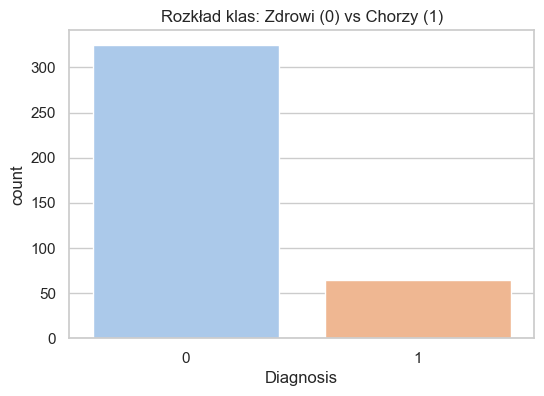

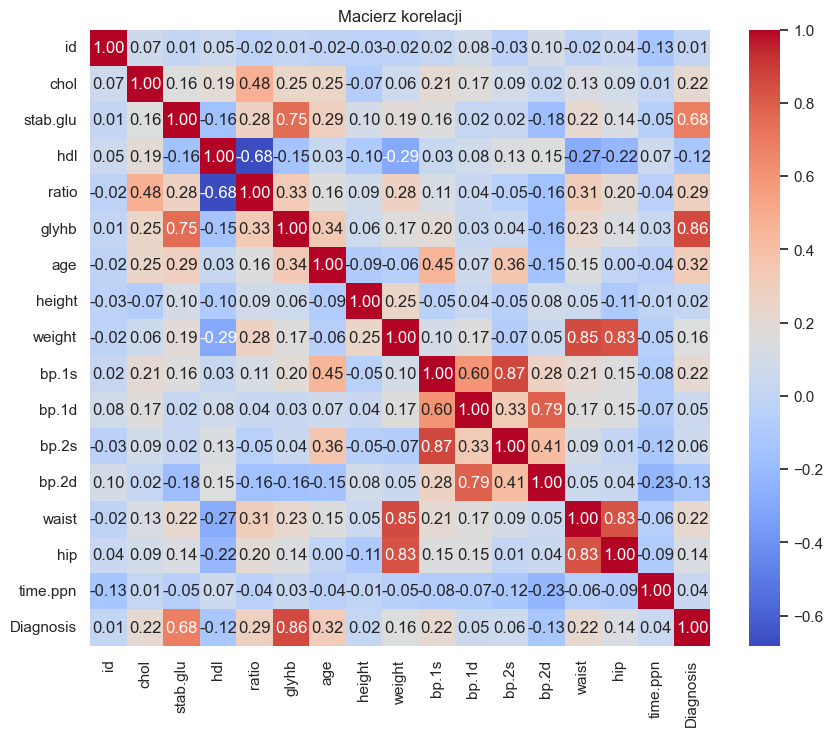

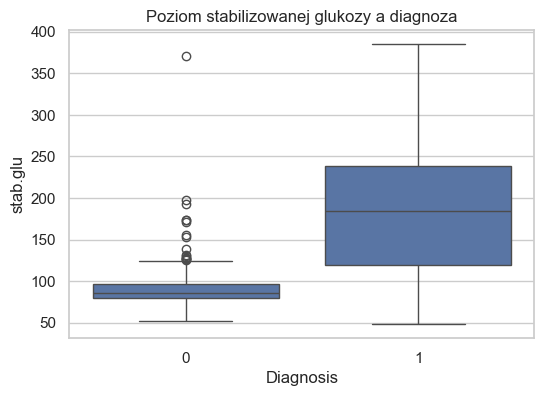

In [3]:
# Wizualizacja

# 1. Histogram atrybutu decyzyjnego
plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df, palette='pastel')
plt.title('Rozkład klas: Zdrowi (0) vs Chorzy (1)')
plt.show()

# 2. Korelacja zmiennych numerycznych
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji')
plt.show()

# 3. Rozkład glukozy
plt.figure(figsize=(6, 4))
sns.boxplot(x='Diagnosis', y='stab.glu', data=df)
plt.title('Poziom stabilizowanej glukozy a diagnoza')
plt.show()

## FAZA 4: Przygotowanie danych
W tej fazie surowe dane zostały poddane procesom czyszczenia, transformacji i selekcji, aby zmaksymalizować skuteczność algorytmów uczenia maszynowego.

**1. Uzupełnianie braków danych:**
* **Ciśnienie krwi:** Zastosowano logikę dziedzinową – w przypadku braku drugiego pomiaru (`bp.2s/d`), przyjęto wartość z pierwszego pomiaru, zakładając stabilność parametru w krótkim czasie.
* **Zmienne numeryczne:** Pozostałe braki uzupełniono **medianą**. Wybrano tę metodę zamiast średniej ze względu na występowanie wartości odstających, które są typowe dla danych medycznych i mogłyby zaburzyć średnią.
* **Zmienne kategoryczne:** Braki w opisach tekstowych uzupełniono **modą** (wartością najczęstszą).

**2. Inżynieria cech (Feature Engineering):**
W celu wydobycia ukrytych informacji utworzono nowe zmienne diagnostyczne:
* **`avg_systolic` / `avg_diastolic`:** Obliczono średnie ciśnienie z dwóch pomiarów, co pozwala zredukować szum pomiarowy i uzyskać bardziej wiarygodny wynik.
* **`WHR` (Waist-to-Hip Ratio):** Wyliczono wskaźnik talia-biodra. Jest to silniejszy predyktor ryzyka metabolicznego i cukrzycy niż same obwody ciała.

**3. Transformacje i Kodowanie:**
* **Korekta rozkładu:** Dla zmiennych o silnej skośności prawostronnej (`chol` - cholesterol, `stab.glu` - glukoza) zastosowano **transformację logarytmiczną (`log1p`)**. Operacja ta zbliżyła rozkłady do normalnego, co jest kluczowe dla efektywności modeli liniowych i opartych na odległości.
* **Kodowanie zmiennych:** Zmienne tekstowe (np. płeć, budowa ciała) zamieniono na wartości liczbowe przy użyciu `LabelEncoder`.

**4. Selekcja cech i eliminacja wycieku danych:**
Usunięto ze zbioru kolumny, które nie powinny brać udziału w treningu:
* **Redukcja nadmiarowości:** Usunięto zmienne składowe (`waist`, `hip`, `bp.1`, `bp.2`) oraz zmienne poddane logarytmizacji, aby uniknąć współliniowości (dublowania informacji).
* **Szum:** Usunięto identyfikatory (`id`) i lokalizację (`location`).
* **Zapobieganie wyciekowi danych (Target Leakage):** Kluczowym krokiem było usunięcie kolumny **`glyhb`** (hemoglobina glikowana). Ponieważ zmienna ta posłużyła do utworzenia etykiety `Diagnosis`, jej pozostawienie w danych treningowych doprowadziłoby do sztucznego zawyżenia wyników modelu.

In [4]:
# Krok 1: Uzupełnianie braków
# Ciśnienie
df['bp.2s'] = df['bp.2s'].fillna(df['bp.1s'])
df['bp.2d'] = df['bp.2d'].fillna(df['bp.1d'])

# Kolumny numeryczne (mediana)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Kolumny kategoryczne (moda)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Krok 2: Tworzenie nowych cech
# Średnie ciśnienie
df['avg_systolic'] = (df['bp.1s'] + df['bp.2s']) / 2
df['avg_diastolic'] = (df['bp.1d'] + df['bp.2d']) / 2

# WHR (Talia / Biodra)
if 'waist' in df.columns and 'hip' in df.columns:
    df['WHR'] = df['waist'] / df['hip']

# Logarytmy
skewed_cols = ['chol', 'stab.glu']
for col in skewed_cols:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

# Krok 3: Label Encoding
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Krok 4: Usuwanie zbędnych kolumn
cols_to_drop = [
    'id', 'location', 
    'waist', 'hip',       # Zastąpione przez WHR
    'ratio',              # Zastąpione przez log_chol i hdl
    'bp.1s', 'bp.2s', 'bp.1d', 'bp.2d', # Zastąpione przez średnie
    'chol', 'stab.glu',   # Zastąpione przez logarytmy
    'glyhb'               # Zastąpione przez Diagnosis
]

df_final = df.drop(columns=cols_to_drop, errors='ignore')

display(df_final.head())

# Ponowne sprawdzenie info czy są jeszcze jakieś braki
print(df_final.info())

,hdl,age,gender,height,weight,frame,time.ppn,Diagnosis,avg_systolic,avg_diastolic,WHR,log_chol,log_stab.glu
0,56.0,46,0,62.0,121.0,1,720.0,0,118.0,59.0,0.763158,5.318120,4.418841
1,24.0,29,0,64.0,218.0,0,360.0,0,112.0,68.0,0.958333,5.111988,4.584967
2,37.0,58,0,61.0,256.0,0,180.0,0,187.5,92.0,0.859649,5.433722,4.532599
3,12.0,67,1,67.0,119.0,0,480.0,0,110.0,50.0,0.868421,4.369448,4.543295
4,28.0,64,1,68.0,183.0,1,300.0,1,138.0,80.0,1.073171,5.521461,4.510860


<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 0 to 401
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hdl            390 non-null    float64
 1   age            390 non-null    int64  
 2   gender         390 non-null    int64  
 3   height         390 non-null    float64
 4   weight         390 non-null    float64
 5   frame          390 non-null    int64  
 6   time.ppn       390 non-null    float64
 7   Diagnosis      390 non-null    int64  
 8   avg_systolic   390 non-null    float64
 9   avg_diastolic  390 non-null    float64
 10  WHR            390 non-null    float64
 11  log_chol       390 non-null    float64
 12  log_stab.glu   390 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 42.7 KB
None


## FAZA 5: Modelowanie – Budowa i optymalizacja algorytmów
W tej fazie przystąpiono do treningu modeli uczenia maszynowego. Ze względu na medyczny charakter problemu (konieczność minimalizacji ryzyka nie wykrycia choroby), proces modelowania został ściśle ukierunkowany na maksymalizację czułości (*Recall*).

**1. Strategia podziału danych:**
Zbiór danych podzielono na część treningową (80%) i testową (20%).
* **Stratyfikacja (`stratify=y`):** Zastosowano podział warstwowy, aby zagwarantować, że w obu podzbiorach zostanie zachowana identyczna proporcja osób chorych do zdrowych. Jest to krytyczne przy niezbalansowanych danych.

**2. Przygotowanie danych do algorytmów:**
* **Standaryzacja (`StandardScaler`):** Dane numeryczne zostały przeskalowane (średnia=0, odchylenie=1). Jest to wymóg konieczny dla algorytmów opartych na obliczaniu odległości (KNN) oraz optymalizacji gradientowej (Regresja Logistyczna).

**3. Wybór algorytmów:**
Przetestowano trzy zróżnicowane podejścia klasyfikacyjne:
* **Regresja Logistyczna (*Logistic Regression*):** Model liniowy, służący jako punkt odniesienia (*baseline*). Zastosowano parametr `class_weight='balanced'`, aby zwiększyć karę za błędy na klasie mniejszościowej (chorych).
* **K-Najbliższych Sąsiadów (*KNN*):** Algorytm oparty na odległości geometrycznej, potrafiący wyłapać lokalne skupiska chorych pacjentów.
* **Las Losowy (*Random Forest*):** Złożony model zespołowy (*ensemble*), odporny na przeuczenie i dobrze radzący sobie z nieliniowymi zależnościami. Również tutaj zastosowano automatyczne równoważenie wag klas.

**4. Strojenie hiperparametrów:**
Dla każdego modelu przeprowadzono proces optymalizacji parametrów przy użyciu **`GridSearchCV`** z 5-krotną walidacją krzyżową (*Cross-Validation*).
* **Kryterium oceny:** Jako metrykę wiodącą wybrano `Recall`. Algorytm automatycznie wybierał taką kombinację parametrów (np. liczbę sąsiadów w KNN czy głębokość drzewa w Random Forest), która skutkowała najmniejszą liczbą przeoczonych diagnoz (*False Negatives*).

In [5]:
# FAZA 5: Modelowanie

# 1. Podział na X (cechy) i y (target)
X = df_final.drop(columns=['Diagnosis'])
y = df_final['Diagnosis']

# 2. Podział na zbiór treningowy i testowy 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Skalowanie danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definicja 3 Modeli i Hiperparametrów do przetestowania 

models_params = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced'), 
        'params': {'C': [0.1, 1, 10], 'solver': ['liblinear']}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9]}
    }
}

best_models = {}
results = []

for model_name, mp in models_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='recall')
    
    # Dla Drzew Losowych skalowanie nie jest konieczne
    # Dla KNN i RegLog użyto danych przeskalowanych
    if model_name == 'Random Forest':
        clf.fit(X_train, y_train)
    else:
        clf.fit(X_train_scaled, y_train)
        
    best_models[model_name] = clf.best_estimator_
    results.append({
        'Model': model_name,
        'Best Score (CV)': clf.best_score_,
        'Best Params': clf.best_params_
    })

# Wyświetlenie wyników
results_df = pd.DataFrame(results)
display(results_df)

,Model,Best Score (CV),Best Params
0,Logistic Regression,0.881818,"{'C': 0.1, 'solver': 'liblinear'}"
1,Random Forest,0.672727,"{'max_depth': 5, 'n_estimators': 200}"
2,KNN,0.501818,{'n_neighbors': 3}


## FAZA 6: Ewaluacja – Ocena i selekcja najlepszych modeli
Po etapie treningu przeprowadzono ostateczną weryfikację skuteczności modeli na odseparowanym zbiorze testowym (20% danych). Celem tej fazy było sprawdzenie, jak modele radzą sobie w warunkach rzeczywistych.

**1. Analiza Metryk:**
Zamiast polegać wyłącznie na ogólnej dokładności (*Accuracy*), która może być myląca przy niezbalansowanych danych, szczegółowej analizie poddano:
* **Recall dla klasy 1 - Chory:** Jest to krytyczny parametr w medycynie. Określa, jaki procent rzeczywiście chorych pacjentów został poprawnie zdiagnozowany przez model.
* **Precision:** Informuje o wiarygodności alarmów (ile osób uznanych za chore faktycznie choruje).

**2. Analiza Macierzy Pomyłek (Confusion Matrix):**
Dla każdego modelu wygenerowano graficzną macierz błędów. Kluczowym obszarem analizy był **lewy dolny róg macierzy (False Negatives)**. Reprezentuje on liczbę pacjentów chorych, których model błędnie uznał za zdrowych.

Model: Logistic Regression
Dokładność (Accuracy): 0.8718
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        65
           1       0.57      1.00      0.72        13

    accuracy                           0.87        78
   macro avg       0.78      0.92      0.82        78
weighted avg       0.93      0.87      0.88        78



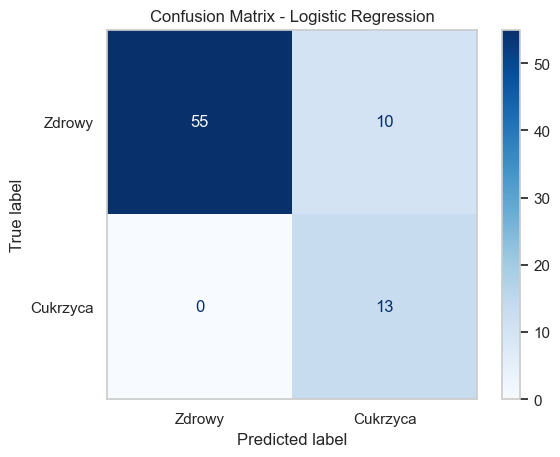

Model: Random Forest
Dokładność (Accuracy): 0.9103
              precision    recall  f1-score   support

           0       0.94      0.95      0.95        65
           1       0.75      0.69      0.72        13

    accuracy                           0.91        78
   macro avg       0.84      0.82      0.83        78
weighted avg       0.91      0.91      0.91        78



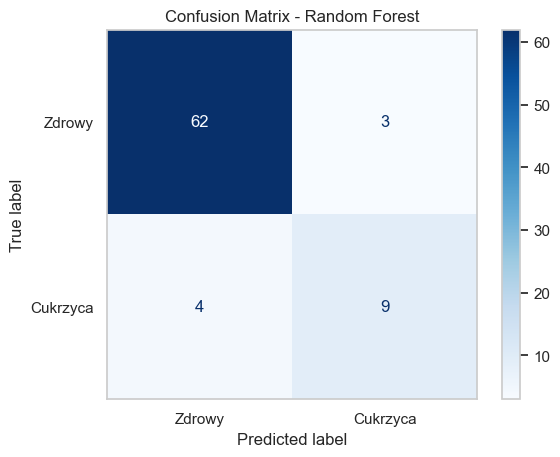

Model: KNN
Dokładność (Accuracy): 0.8462
              precision    recall  f1-score   support

           0       0.87      0.95      0.91        65
           1       0.57      0.31      0.40        13

    accuracy                           0.85        78
   macro avg       0.72      0.63      0.66        78
weighted avg       0.82      0.85      0.83        78



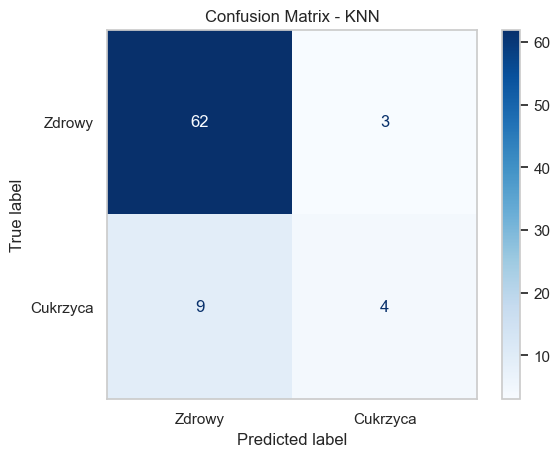

In [ ]:
# FAZA 6: Ewaluacja modeli na zbiorze testowym 

for model_name, model in best_models.items():
    print(f"Model: {model_name}")
    
    # Wybór odpowiednich danych (skalowane lub nie)
    if model_name == 'Random Forest':
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)
        
    # Metryki
    acc = accuracy_score(y_test, y_pred)
    print(f"Dokładność (Accuracy): {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    # Macierz pomyłek
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Zdrowy', 'Cukrzyca'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.grid(False)
    plt.show()

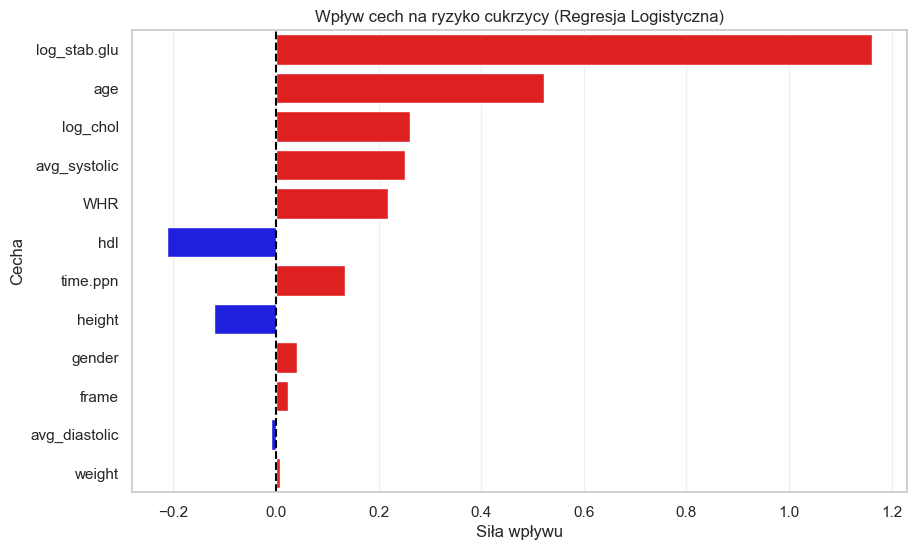

In [ ]:
# 1. Wybrano model regresji liniowej i dla niego zostaną zweryfikowane wpływy zmiennych na wynik
best_lr = best_models['Logistic Regression']

# 2. Pobrano wagi przypisane każdej cesze
coefficients = best_lr.coef_[0]
feature_names = X.columns.tolist()

# 3. Tworzenie tabeli do wykresu
feat_imp = pd.DataFrame({
    'Cecha': feature_names,
    'Waga': coefficients,
    'Wpływ (Abs)': np.abs(coefficients) # Siła wpływu
})

# Sortowanie dla wykresu
feat_imp = feat_imp.sort_values(by='Wpływ (Abs)', ascending=False)

# 4.Wykres
plt.figure(figsize=(10, 6))
# Kolor Czerwony dla czynników ryzyka dodatnich
colors = ['red' if x > 0 else 'blue' for x in feat_imp['Waga']]
sns.barplot(x='Waga', y='Cecha', data=feat_imp, palette=colors)

plt.title('Wpływ cech na ryzyko cukrzycy (Regresja Logistyczna)')
plt.xlabel('Siła wpływu')
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(True, axis='x', alpha=0.3)
plt.show()

## FAZA 7: Wdrożenie i Wnioski Końcowe

**1. Charakterystyka rozwiązania:**
Wybrano model Regresji Logistycznej, który działa jak bardzo czułe "sito".
* **Bezpieczeństwo:** Model gwarantuje, że ryzyko odesłania do domu osoby chorej jest zminimalizowane do zera (na podstawie zbioru testowego).
* **Koszt:** Ceną za tak wysoką czułość jest nadreprezentacja osób zdrowych w grupie ryzyka.

**2. Wnioski analityczne:**
Analiza wag modelu Regresji Logistycznej potwierdziła istotność zmiennych:
* **Glukoza (`stab.glu`):** Najsilniejszy predyktor dodatni.
* **Wiek (`age`):** Istotny czynnik ryzyka.
* **WHR:** Potwierdzono użyteczność wskaźnika talia-biodra.

**3. Ograniczenia:**
* **Wielkość próby:** Zbiór danych 403 pacjentów jest stosunkowo mały.
* **Zastosowanie:** Model nie zastępuje lekarza, ale służy jako system drugiej opinii dla pacjentów z grupy ryzyka.